In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score


In [38]:
# Direct link to the dataset containing all your required attributes
dataset_url = "https://raw.githubusercontent.com/py-why/EconML/refs/heads/data/datasets/EmployeeAttrition/Employee-Attrition.csv"

# Load the data into a DataFrame
df = pd.read_csv(dataset_url)

# Print columns to verify your attributes are there
print(df[['Age', 'Department', 'DistanceFromHome', 'EducationField', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'YearsAtCompany','Attrition']].head())


   Age              Department  DistanceFromHome EducationField  \
0   41                   Sales                 1  Life Sciences   
1   49  Research & Development                 8  Life Sciences   
2   37  Research & Development                 2          Other   
3   33  Research & Development                 3  Life Sciences   
4   27  Research & Development                 2        Medical   

   JobSatisfaction  MonthlyIncome  NumCompaniesWorked  YearsAtCompany  \
0                4           5993                   8               6   
1                2           5130                   1              10   
2                3           2090                   6               0   
3                3           2909                   1               8   
4                2           3468                   9               2   

  Attrition  
0       Yes  
1        No  
2       Yes  
3        No  
4        No  


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [40]:
df = df[['Age', 'Department', 'DistanceFromHome', 'EducationField', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'YearsAtCompany','Attrition']]

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 1470 non-null   int64 
 1   Department          1470 non-null   object
 2   DistanceFromHome    1470 non-null   int64 
 3   EducationField      1470 non-null   object
 4   JobSatisfaction     1470 non-null   int64 
 5   MonthlyIncome       1470 non-null   int64 
 6   NumCompaniesWorked  1470 non-null   int64 
 7   YearsAtCompany      1470 non-null   int64 
 8   Attrition           1470 non-null   object
dtypes: int64(6), object(3)
memory usage: 103.5+ KB


In [42]:
df.head()

,Age,Department,DistanceFromHome,EducationField,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,YearsAtCompany,Attrition
0,41,Sales,1,Life Sciences,4,5993,8,6,Yes
1,49,Research & Development,8,Life Sciences,2,5130,1,10,No
2,37,Research & Development,2,Other,3,2090,6,0,Yes
3,33,Research & Development,3,Life Sciences,3,2909,1,8,No
4,27,Research & Development,2,Medical,2,3468,9,2,No


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.isnull().sum().sum()

np.int64(0)

In [45]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [46]:
df.head()

,Age,Department,DistanceFromHome,EducationField,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,YearsAtCompany,Attrition
0,41,Sales,1,Life Sciences,4,5993,8,6,1
1,49,Research & Development,8,Life Sciences,2,5130,1,10,0
2,37,Research & Development,2,Other,3,2090,6,0,1
3,33,Research & Development,3,Life Sciences,3,2909,1,8,0
4,27,Research & Development,2,Medical,2,3468,9,2,0


In [47]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
categorical_cols = ['Department', 'EducationField']
encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)
df.head()

,Age,DistanceFromHome,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,YearsAtCompany,Attrition,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,41,1,4,5993,8,6,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,49,8,2,5130,1,10,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,37,2,3,2090,6,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33,3,3,2909,1,8,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,27,2,2,3468,9,2,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


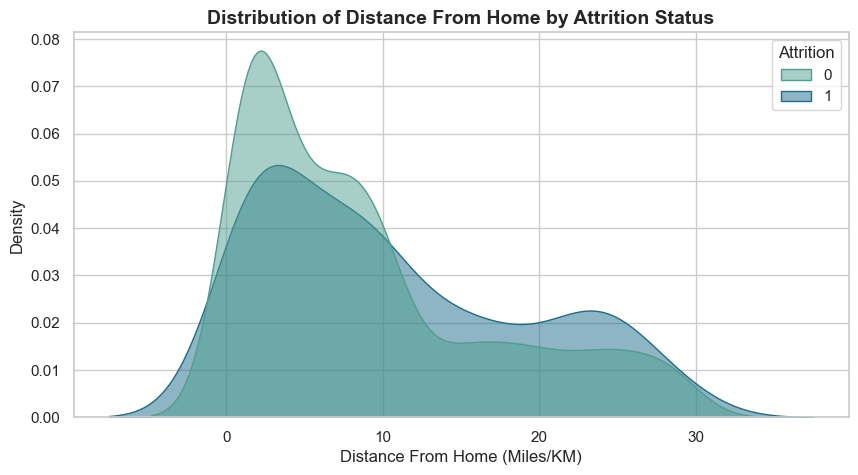

In [48]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='DistanceFromHome', hue='Attrition', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of Distance From Home by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Distance From Home (Miles/KM)')
plt.ylabel('Density')
plt.show()

In [49]:
# Identify continuous numerical features that need scaling
numerical_cols = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'YearsAtCompany']
numerical_cols = [col for col in numerical_cols if col in df.columns]

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Preview the cleaned and processed dataframe
print("\n--- Processed Dataset Preview ---")
print(df.head())


--- Processed Dataset Preview ---
        Age  DistanceFromHome  JobSatisfaction  MonthlyIncome  \
0  0.446350         -1.010909                4      -0.108350   
1  1.322365         -0.147150                2      -0.291719   
2  0.008343         -0.887515                3      -0.937654   
3 -0.429664         -0.764121                3      -0.763634   
4 -1.086676         -0.887515                2      -0.644858   

   NumCompaniesWorked  YearsAtCompany  Attrition  \
0            2.125136       -0.164613          1   
1           -0.678049        0.488508          0   
2            1.324226       -1.144294          1   
3           -0.678049        0.161947          0   
4            2.525591       -0.817734          0   

   Department_Research & Development  Department_Sales  \
0                                0.0               1.0   
1                                1.0               0.0   
2                                1.0               0.0   
3                            

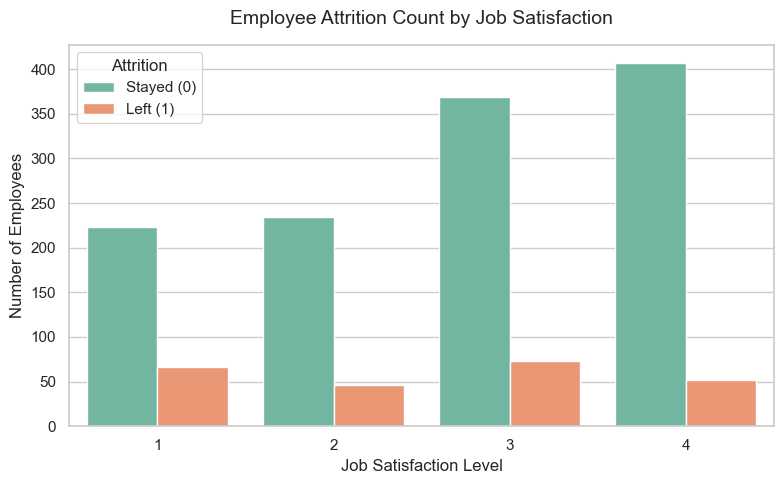

In [50]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
# Using JobSatisfaction from your exact column list
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', palette='Set2')

plt.title('Employee Attrition Count by Job Satisfaction', fontsize=14, pad=15)
plt.xlabel('Job Satisfaction Level', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['Stayed (0)', 'Left (1)'])

plt.tight_layout()
plt.show()

C:\Users\abhijit\AppData\Local\Temp\ipykernel_716\1502784308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Pastel1')


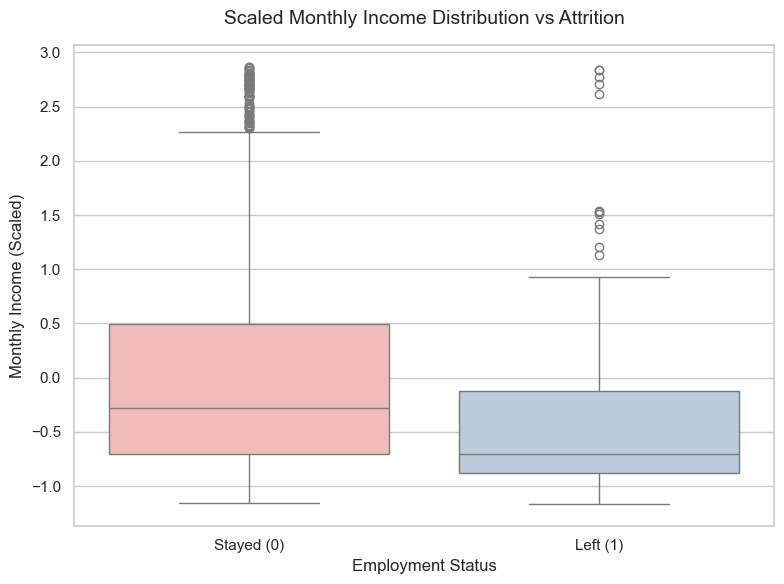

In [51]:
plt.figure(figsize=(8, 6))
# Using MonthlyIncome and Attrition from your exact column list
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Pastel1')

plt.title('Scaled Monthly Income Distribution vs Attrition', fontsize=14, pad=15)
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])
plt.xlabel('Employment Status', fontsize=12)
plt.ylabel('Monthly Income (Scaled)', fontsize=12)

plt.tight_layout()
plt.show()

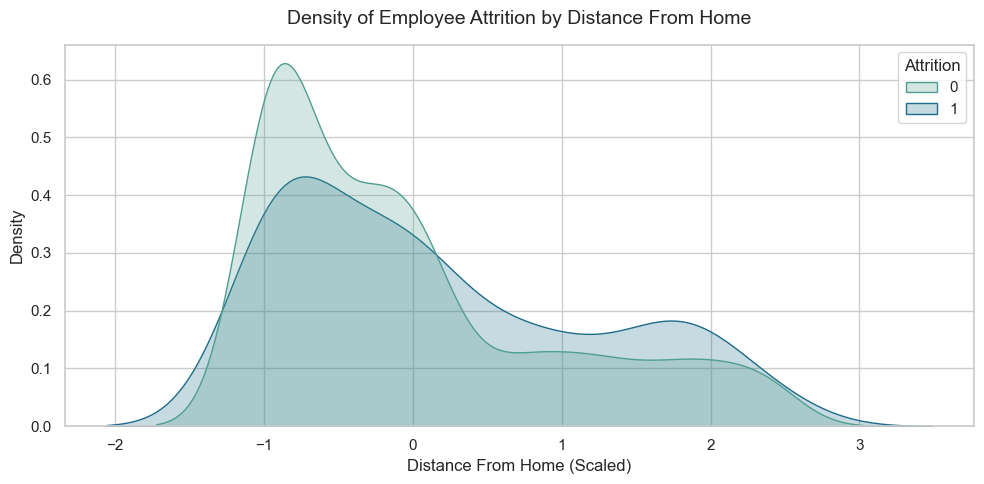

In [52]:
plt.figure(figsize=(10, 5))
# Using DistanceFromHome from your exact column list
sns.kdeplot(data=df, x='DistanceFromHome', hue='Attrition', fill=True, common_norm=False, palette='crest')

plt.title('Density of Employee Attrition by Distance From Home', fontsize=14, pad=15)
plt.xlabel('Distance From Home (Scaled)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.show()

In [53]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Split the data (80% training, 20% testing)
# stratify=y ensures that the proportion of people who left vs stayed is identical in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(# Training shapes
f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (1176, 13)
Testing Features Shape: (294, 13)


In [54]:
# Initialize models
log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)

# Train Logistic Regression
log_reg.fit(X_train, y_train)

# Train Random Forest
rf_clf.fit(X_train, y_train)

print("Both models have been successfully trained!")

Both models have been successfully trained!


In [55]:
# Retrain Logistic Regression with balanced class weights
log_reg_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg_balanced.fit(X_train, y_train)

# Retrain Random Forest with balanced class weights
rf_clf_balanced = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_clf_balanced.fit(X_train, y_train)

# Evaluate the newly balanced models
balanced_models = {
    "Balanced Logistic Regression": log_reg_balanced,
    "Balanced Random Forest": rf_clf_balanced
}

for name, model in balanced_models.items():
    y_pred = model.predict(X_test)
    print(f"\n================ {name} Performance ================")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))


================ Balanced Logistic Regression Performance ================
Accuracy : 0.6429
Precision: 0.2315
Recall   : 0.5319

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.76       247
           1       0.23      0.53      0.32        47

    accuracy                           0.64       294
   macro avg       0.56      0.60      0.54       294
weighted avg       0.78      0.64      0.69       294


================ Balanced Random Forest Performance ================
Accuracy : 0.8095
Precision: 0.2000
Recall   : 0.0638

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       247
           1       0.20      0.06      0.10        47

    accuracy                           0.81       294
   macro avg       0.52      0.51      0.50       294
weighted avg       0.74      0.81      0.77       294



C:\Users\abhijit\AppData\Local\Temp\ipykernel_716\119604484.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='vlag')


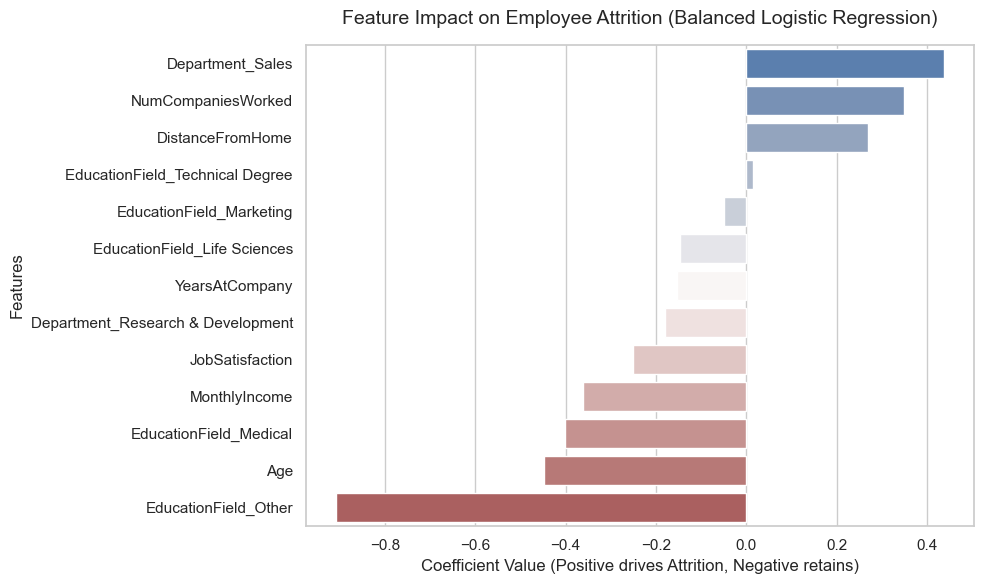


--- Top Attrition Drivers ---
              Feature  Coefficient
7    Department_Sales     0.436691
4  NumCompaniesWorked     0.349065
1    DistanceFromHome     0.269334


In [56]:
# Extract coefficients from your winning model
coefficients = log_reg_balanced.coef_[0]
feature_names = X.columns

# Create a DataFrame to organize them
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Plotting the impact of each feature
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='vlag')
plt.title('Feature Impact on Employee Attrition (Balanced Logistic Regression)', fontsize=14, pad=15)
plt.xlabel('Coefficient Value (Positive drives Attrition, Negative retains)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- Top Attrition Drivers ---")
print(importance_df.head(3))

In [57]:
# Predict probabilities for the test dataset
#[:, 1] isolates the probability of class 1 (leaving)
test_probabilities = log_reg_balanced.predict_proba(X_test)[:, 1]

# Reconstruct a clear view for HR
watchlist_df = pd.DataFrame({
    'Actual_Status': y_test.values,
    'Risk_Score': test_probabilities
})

# Let's add back some context columns from X_test to make it readable
# Resetting index to align properly
X_test_reset = X_test.reset_index(drop=True)
watchlist_df['MonthlyIncome_Scaled'] = X_test_reset['MonthlyIncome']
watchlist_df['JobSatisfaction'] = X_test_reset['JobSatisfaction']

# Sort by highest risk score
high_risk_employees = watchlist_df.sort_values(by='Risk_Score', ascending=False)

print("\n--- Sample of HR Risk Watch List (Top 5 Highest Risk) ---")
print(high_risk_employees.head(5))


--- Sample of HR Risk Watch List (Top 5 Highest Risk) ---
     Actual_Status  Risk_Score  MonthlyIncome_Scaled  JobSatisfaction
158              1    0.850940             -0.409219                3
41               0    0.845894             -0.617448                2
273              0    0.835432             -0.649320                3
95               1    0.823865             -0.446828                1
278              0    0.817113             -0.049068                2


In [58]:
import pickle

# Save the winning balanced model to a file
with open('attrition_logistic_model.pkl', 'wb') as model_file:
    pickle.dump(log_reg_balanced, model_file)

# Save the scaler so HR can process new input data correctly
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Success! 'attrition_logistic_model.pkl' and 'scaler.pkl' have been saved to your workspace.")

Success! 'attrition_logistic_model.pkl' and 'scaler.pkl' have been saved to your workspace.


In [59]:
# 1. Load the saved scaler and model
with open('scaler.pkl', 'rb') as scaler_file:
    loaded_scaler = pickle.load(scaler_file)

with open('attrition_logistic_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

# 2. Simulate new, unseen employee data incoming to HR
# (Make sure features match the exact order of X during training)
new_employee_data = pd.DataFrame([{
    'Age': 28,
    'DistanceFromHome': 18,
    'JobSatisfaction': 1,
    'MonthlyIncome': 2500,
    'NumCompaniesWorked': 5,
    'YearsAtCompany': 1,
    'Department_Research & Development': 0.0,
    'Department_Sales': 1.0,
    'EducationField_Life Sciences': 1.0,
    'EducationField_Marketing': 0.0,
    'EducationField_Medical': 0.0,
    'EducationField_Other': 0.0,
    'EducationField_Technical Degree': 0.0
}])

# 3. Scale the continuous numerical columns using the loaded scaler
numerical_cols = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'YearsAtCompany']
new_employee_data[numerical_cols] = loaded_scaler.transform(new_employee_data[numerical_cols])

# 4. Predict the risk probability score
risk_score = loaded_model.predict_proba(new_employee_data)[0][1]

print("================ HR Production Predictor ================")
print(f"Calculated Attrition Risk Score: {risk_score * 100:.2f}%")

if risk_score >= 0.75:
    print("Action Required: Add this individual to the CRITICAL WATCH LIST immediately.")
else:
    print("Status: Employee is currently stable.")

================ HR Production Predictor ================
Calculated Attrition Risk Score: 89.75%
Action Required: Add this individual to the CRITICAL WATCH LIST immediately.
